# Total Return Swap Pricing — Lou (2018)

**Reference:** W. Lou, *Pricing Total Return Swap*, 2018. SSRN 3217420.

Visual validation of equity TRS with repo financing, trinomial tree, and XVA decomposition.

## Contents
1. FVA as function of repo spread (Eq 8)
2. Full-CSA TRS value vs spot — pre-crisis vs repo-adjusted (Eq 2 vs 7)
3. Bond forward under repo with haircut (Eq 28)
4. Tree convergence to analytic (Section 8.4)
5. XVA decomposition: V* vs V and CVA/DVA/CFA/DFA (Section 5)
6. ATI funding spread: V=0 when sf=0 at ATI Libor

In [ ]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "python"))

import math
import numpy as np
import matplotlib.pyplot as plt
from pricebook.trs_lou import trs_equity_full_csa, trs_fva, trs_precrisis, trs_bond_forward
from pricebook.trs_tree import trs_trinomial_tree, trs_tree_xva

S0 = 100.0; r = 0.10; T = 1.0
D = math.exp(-r * T)
libor = (1/D - 1) / T  # ATI simply-compounded Libor

plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 12})
print(f"S0={S0}, r={r}, D={D:.4f}, Libor(sc)={libor:.4f}")

## 1. FVA vs Repo Spread

$\text{fva} = (e^{(r_s - r)T} - 1) \times S_t \geq 0$

The hedge financing cost grows exponentially with the repo-OIS spread.

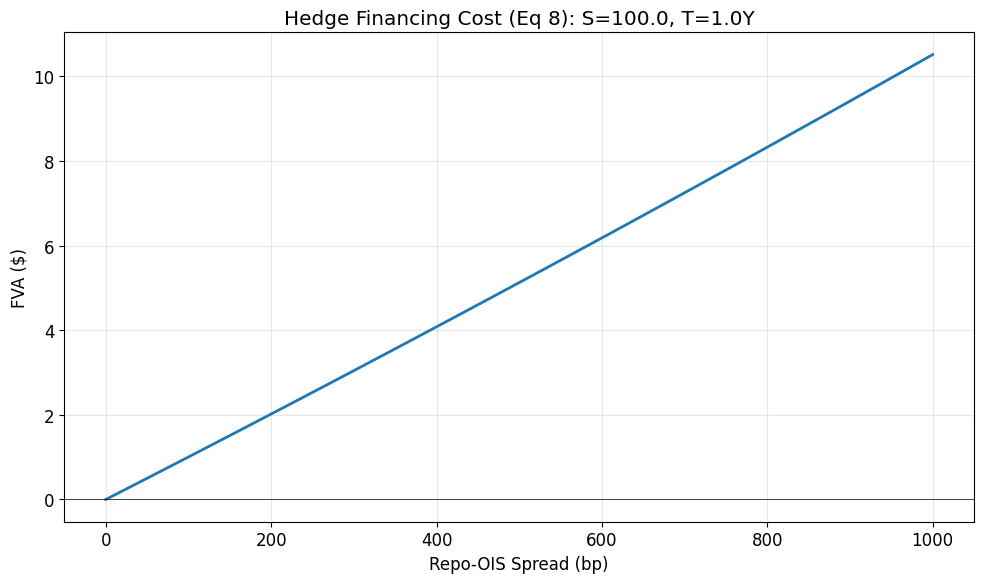

In [2]:
spreads = np.linspace(0, 0.10, 100)
fvas = [trs_fva(S0, rs, T) for rs in spreads]

fig, ax = plt.subplots()
ax.plot(spreads * 10000, fvas, lw=2)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("Repo-OIS Spread (bp)")
ax.set_ylabel("FVA ($)")
ax.set_title(f"Hedge Financing Cost (Eq 8): S={S0}, T={T}Y")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. TRS Value vs Spot — Pre-Crisis vs Repo-Adjusted

Pre-crisis (Eq 2) vs full-CSA with repo (Eq 7). The repo-adjusted value is lower by the fva.

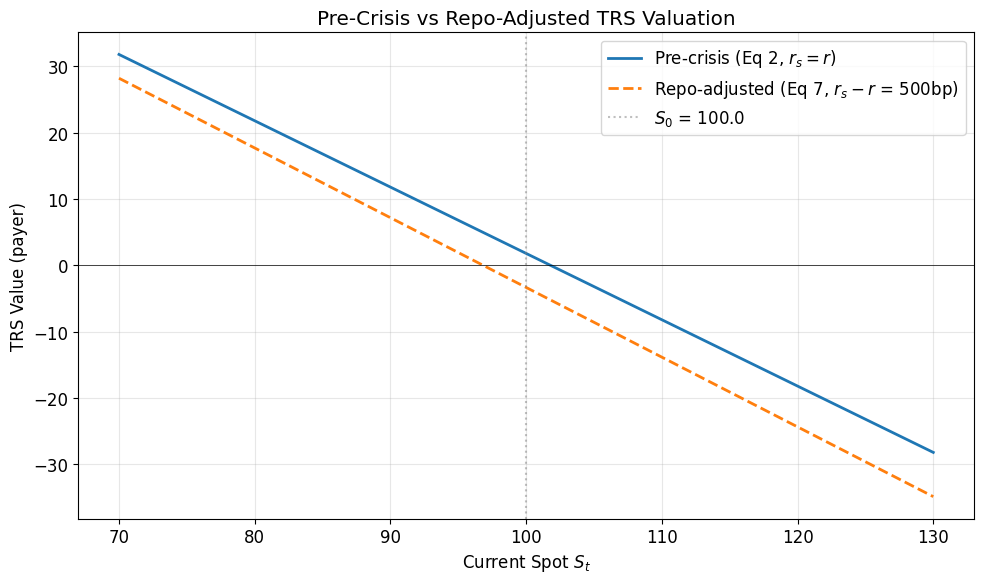

In [3]:
spots = np.linspace(70, 130, 100)
sf = 0.02; r_f = libor + sf

v_precrisis = [(S0 * r_f * T + S0) * D - s for s in spots]
v_repo = [trs_equity_full_csa(s, S0, r_f, T, 0.0, D, rs_minus_r=0.05).value for s in spots]

fig, ax = plt.subplots()
ax.plot(spots, v_precrisis, lw=2, label="Pre-crisis (Eq 2, $r_s = r$)")
ax.plot(spots, v_repo, "--", lw=2, label="Repo-adjusted (Eq 7, $r_s - r$ = 500bp)")
ax.axhline(0, color="k", lw=0.5)
ax.axvline(S0, ls=":", color="gray", alpha=0.5, label=f"$S_0$ = {S0}")
ax.set_xlabel("Current Spot $S_t$")
ax.set_ylabel("TRS Value (payer)")
ax.set_title("Pre-Crisis vs Repo-Adjusted TRS Valuation")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Bond Forward under Repo with Haircut

$F = B_t e^{\bar{r}_s T} - \sum c_i e^{\bar{r}_s(T - T_i)}$ where $\bar{r}_s = (1-h)r_s + h r_N$

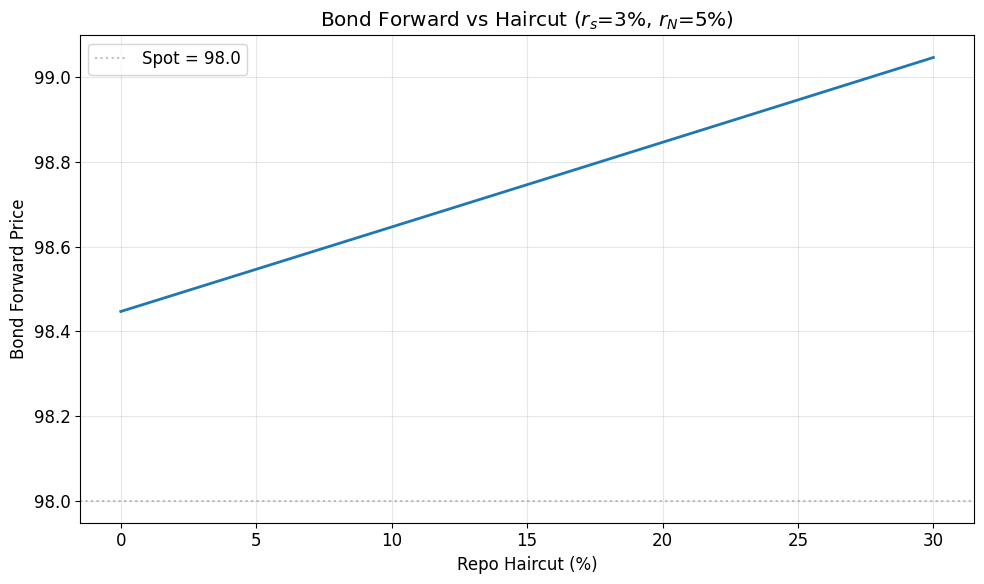

In [4]:
B_t = 98.0
coupons = [(0.5, 2.5)]  # semi-annual 5% coupon on 100 face

haircuts = np.linspace(0, 0.30, 50)
rs = 0.03; rN = 0.05
forwards = []
for h in haircuts:
    rs_bar = (1 - h) * rs + h * rN
    fwd = trs_bond_forward(B_t, rs_bar, T=1.0, coupons=coupons, lambda_val=0.0)
    forwards.append(fwd)

fig, ax = plt.subplots()
ax.plot(haircuts * 100, forwards, lw=2)
ax.axhline(B_t, ls=":", color="gray", alpha=0.5, label=f"Spot = {B_t}")
ax.set_xlabel("Repo Haircut (%)")
ax.set_ylabel("Bond Forward Price")
ax.set_title(f"Bond Forward vs Haircut ($r_s$={rs*100:.0f}%, $r_N$={rN*100:.0f}%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Tree Convergence to Analytic

The trinomial tree (Eq 12) with full CSA should converge to the analytic closed form (Eq 7) as n_steps increases.

In [ ]:
# Tree convergence
sigma = 0.20; rs_minus_r = 0.02; r_f = libor

analytic = trs_equity_full_csa(S0, S0, r_f, T, 0.0, D, rs_minus_r=rs_minus_r)

steps = [10, 20, 50, 100, 200, 500]
tree_vals = []
for n in steps:
    tree = trs_trinomial_tree(S0, r_f, T, r, rs_minus_r, sigma, n_steps=n, mu=1.0)
    tree_vals.append(tree.value)

fig, ax = plt.subplots()
ax.plot(steps, tree_vals, "bo-", lw=2, ms=6, label="Tree")
ax.axhline(analytic.value, ls="--", color="r", lw=2, label=f"Analytic (Eq 7) = {analytic.value:.4f}")
ax.set_xlabel("Number of Steps")
ax.set_ylabel("TRS Value")
ax.set_title(f"Tree Convergence to Analytic ($\\sigma$={sigma*100:.0f}%, $r_s-r$={rs_minus_r*10000:.0f}bp)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Analytic: {analytic.value:.6f}")
for n, v in zip(steps, tree_vals):
    print(f"  n={n:>4d}: {v:>12.6f}  error={abs(v-analytic.value):.6f}")

## 5. XVA Decomposition

$U = V^* - V = \text{CVA} - \text{DVA} + \text{CFA} - \text{DFA}$

With asymmetric funding ($r_b \neq r_c$), the switching discount rate creates an XVA wedge between OIS-discounted and actual value.

In [ ]:
# XVA decomposition as function of customer credit spread
sigma = 0.30
sc_range = np.linspace(0.001, 0.10, 30)

cvas, dvas, cfas, dfas, totals = [], [], [], [], []
for sc in sc_range:
    result = trs_tree_xva(
        S_0=S0, r_f=libor, T=T, r=r, rs_minus_r=0.02,
        sigma=sigma, r_b=0.12, r_c=r + sc + 0.005,
        s_b=0.017, s_c=sc, mu_b=0.003, mu_c=0.005,
        n_steps=50, mu=0.0)
    cvas.append(result.cva)
    dvas.append(result.dva)
    cfas.append(result.cfa)
    dfas.append(result.dfa)
    totals.append(result.total_xva)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(sc_range * 10000, totals, "k-", lw=2, label="Total XVA ($U$)")
ax1.axhline(0, color="gray", lw=0.5)
ax1.set_xlabel("Customer CDS spread $s_c$ (bp)")
ax1.set_ylabel("XVA")
ax1.set_title("Total XVA = $V^* - V$")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(sc_range * 10000, cvas, lw=2, label="CVA")
ax2.plot(sc_range * 10000, dvas, "--", lw=2, label="DVA")
ax2.plot(sc_range * 10000, cfas, ":", lw=2, label="CFA")
ax2.plot(sc_range * 10000, dfas, "-.", lw=2, label="DFA")
ax2.set_xlabel("Customer CDS spread $s_c$ (bp)")
ax2.set_ylabel("XVA Component")
ax2.set_title("XVA Decomposition (Eq 15-18)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. ATI Validation

At-the-issue: with $s_f = 0$ and ATI Libor $\ell = (1/D - 1)/T$, $V_0 = 0$ exactly.

In [ ]:
# ATI: sf = 0, rf = libor => V = 0 exactly
spreads_sf = np.linspace(-0.03, 0.05, 100)
ati_values = []
for sf in spreads_sf:
    rf = libor + sf
    result = trs_equity_full_csa(S0, S0, rf, T, 0.0, D, rs_minus_r=0.0)
    ati_values.append(result.value)

fig, ax = plt.subplots()
ax.plot(spreads_sf * 10000, ati_values, lw=2)
ax.axhline(0, color="k", lw=0.5)
ax.axvline(0, ls=":", color="red", lw=2, label="ATI ($s_f=0$): V=0")
ax.set_xlabel("Funding Spread $s_f$ (bp)")
ax.set_ylabel("TRS Value (payer)")
ax.set_title("TRS Value vs Funding Spread (ATI at $s_f = 0$)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"V at sf=0: {trs_equity_full_csa(S0, S0, libor, T, 0.0, D, rs_minus_r=0.0).value:.2e}")